In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from db_connection import db, Songs, SongAudioFeatures

# Import from CSV
Normally I would use the database, but I decided to use the CSV file for reproducibility.

In [32]:
df_csv = pd.read_csv("songs_export.csv", index_col="id_x")
df_csv.index = df_csv.index.astype(str)
df_csv.index.name = "song_id"

song_name_series = df_csv["song_name"]
artist_series = df_csv["artists"]

audio_col_map = {
    "acousticness": "acousticness",
    "danceability": "danceability",
    "energy": "energy",
    "instrumentalness": "instrumentalness",
    "key": "key",
    "liveness": "liveness",
    "loudness": "loudness",
    "mode": "mode",
    "speechiness": "speechiness",
    "tempo": "tempo",
    "time_signature": "time_signature",
    "valence": "valence",
    "num_samples": "num_samples",
    "duration": "duration",
    "duration_ms": "duration_ms_y",
    "end_of_fade_in": "end_of_fade_in",
    "start_of_fade_out": "start_of_fade_out",
    "tempo_confidence": "tempo_confidence",
    "time_signature_confidence": "time_signature_confidence",
    "key_confidence": "key_confidence",
    "mode_confidence": "mode_confidence",
}
df_audio = df_csv[list(audio_col_map.values())].rename(columns={v: k for k, v in audio_col_map.items()})
df_audio["song_duration_ms"] = df_csv["duration_ms_x"]
df_audio["popularity"] = df_csv["popularity"]
df_audio["explicit"] = df_csv["explicit"].apply(lambda x: int(x) if pd.notna(x) else None)

def parse_embedding(s):
    if pd.isna(s):
        return [np.nan] * 768
    cleaned = " ".join(s.strip("[] \n").split())
    return np.fromstring(cleaned, sep=" ").tolist()

lyrics_emb_columns = [f"lyrics_emb_{i}" for i in range(768)]
lyrics_parsed = df_csv["lyrics_embeddings"].apply(parse_embedding)
df_lyrics_emb = pd.DataFrame(lyrics_parsed.tolist(), index=df_csv.index, columns=lyrics_emb_columns)
df_lyrics_emb.index.name = "song_id"

image_emb_columns = [f"image_emb_{i}" for i in range(768)]
image_parsed = df_csv["image_embeddings"].apply(parse_embedding)
df_image_emb = pd.DataFrame(image_parsed.tolist(), index=df_csv.index, columns=image_emb_columns)
df_image_emb.index.name = "song_id"

print(f"df_audio: {df_audio.shape}")
print(f"df_lyrics_emb: {df_lyrics_emb.shape}")
print(f"df_image_emb: {df_image_emb.shape}")

df_audio: (100, 24)
df_lyrics_emb: (100, 768)
df_image_emb: (100, 768)


In [33]:
df_audio.to_csv("songs_export_audio_features.csv")
df_lyrics_emb.to_csv("songs_export_lyrics_embeddings.csv")
df_image_emb.to_csv("songs_export_image_embeddings.csv")

# Euclidean Distance & Normalization
I normalize the data since not all features are on the same scale. Then I computed the euclidean distance between each song.

In [34]:
def euclidean_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:
    filled = df.fillna(df.median())
    dist_vec = pdist(filled.values, metric="euclidean")
    dist_mat = squareform(dist_vec)
    np.fill_diagonal(dist_mat, np.nan)
    return pd.DataFrame(dist_mat, index=df.index, columns=df.index)
def normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(axis=1, how="all")
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

df_audio_norm = normalize_df(df_audio)
df_lyrics_norm = normalize_df(df_lyrics_emb)
df_image_norm = normalize_df(df_image_emb)
dist_audio = euclidean_distance_matrix(df_audio_norm)
dist_lyrics = euclidean_distance_matrix(df_lyrics_norm)
dist_image = euclidean_distance_matrix(df_image_norm)

In [35]:
for label, raw, normed, dist in [
        ("Audio Features", df_audio, df_audio_norm, dist_audio),
        ("Lyrics Embeddings", df_lyrics_emb, df_lyrics_norm, dist_lyrics),
        ("Image Embeddings", df_image_emb, df_image_norm, dist_image),
    ]:
    print(f"{label}:")
    print(f"  Raw shape:        {raw.shape}")
    print(f"  Normalized range: {normed.min().min():.4f} to {normed.max().max():.4f}")
    print(f"  Distance matrix:  {dist.shape}")
    print(f"  Mean distance:    {dist.values[np.triu_indices_from(dist.values, k=1)].mean():.4f}")
    print()

Audio Features:
  Raw shape:        (100, 24)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    1.7597

Lyrics Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    5.4999

Image Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    8.5255



# Expermenting
Here I experiment with the data. Feel free to skip ahead to the Keys and tempo section, where I answer the assignment's questions.

# K Means Clustering
I'm using K means clustering to group songs based on their features because it's simple and the same methods used in the example. Normally I would use a better method like hierarchical clustering or DBSCAN in a production environment.

In [36]:
def kmeans_cluster(df: pd.DataFrame, n_clusters: int, random_state: int = 42) -> pd.Series:
    filled = df.fillna(df.median())
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(filled.values)
    return pd.Series(labels, index=df.index, name="cluster"), km

# N Clusters
You might be wondering why I chose 2 clusters. I decided through trial and error that this was a good number of clusters to use. Typically I would use a silhouette score to determine the optimal number of clusters, but since we haven't covered that in class yet, I went with 2.

In [37]:
clusters = 2

audio_clusters, audio_km = kmeans_cluster(df_audio_norm, n_clusters=clusters)
lyrics_clusters, lyrics_km = kmeans_cluster(df_lyrics_norm, n_clusters=clusters)
image_clusters, image_km = kmeans_cluster(df_image_norm, n_clusters=clusters)

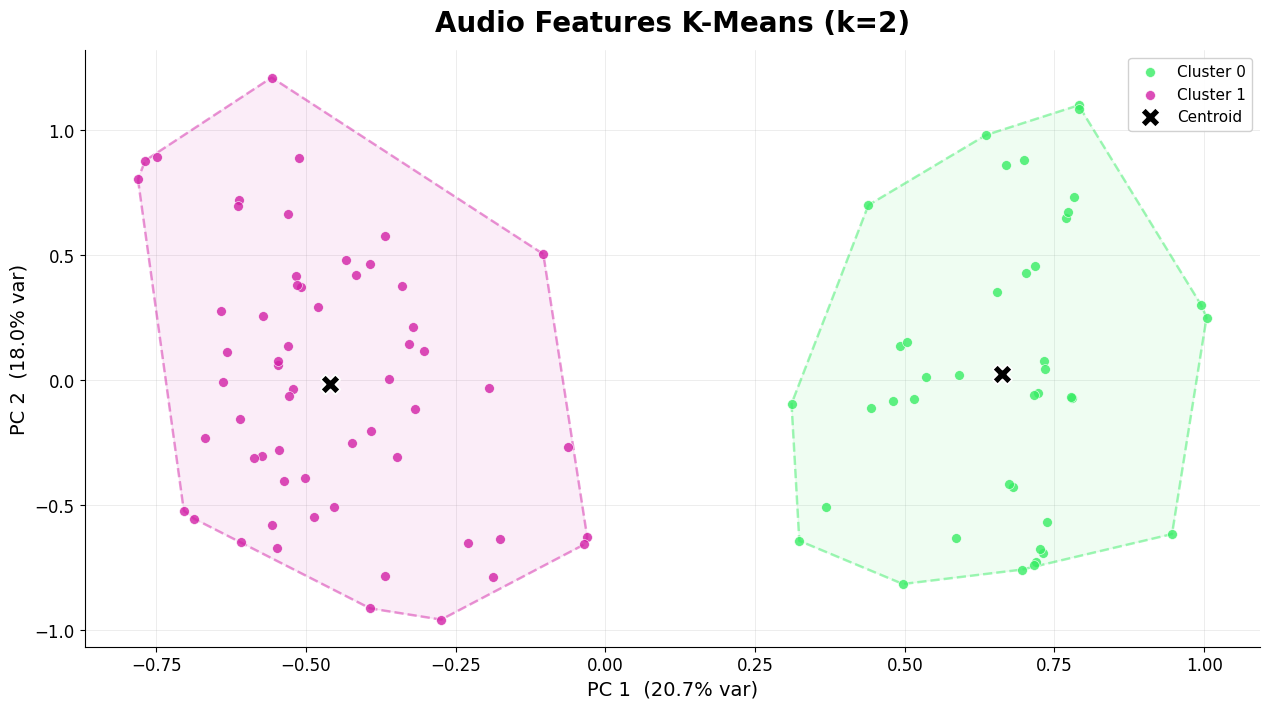

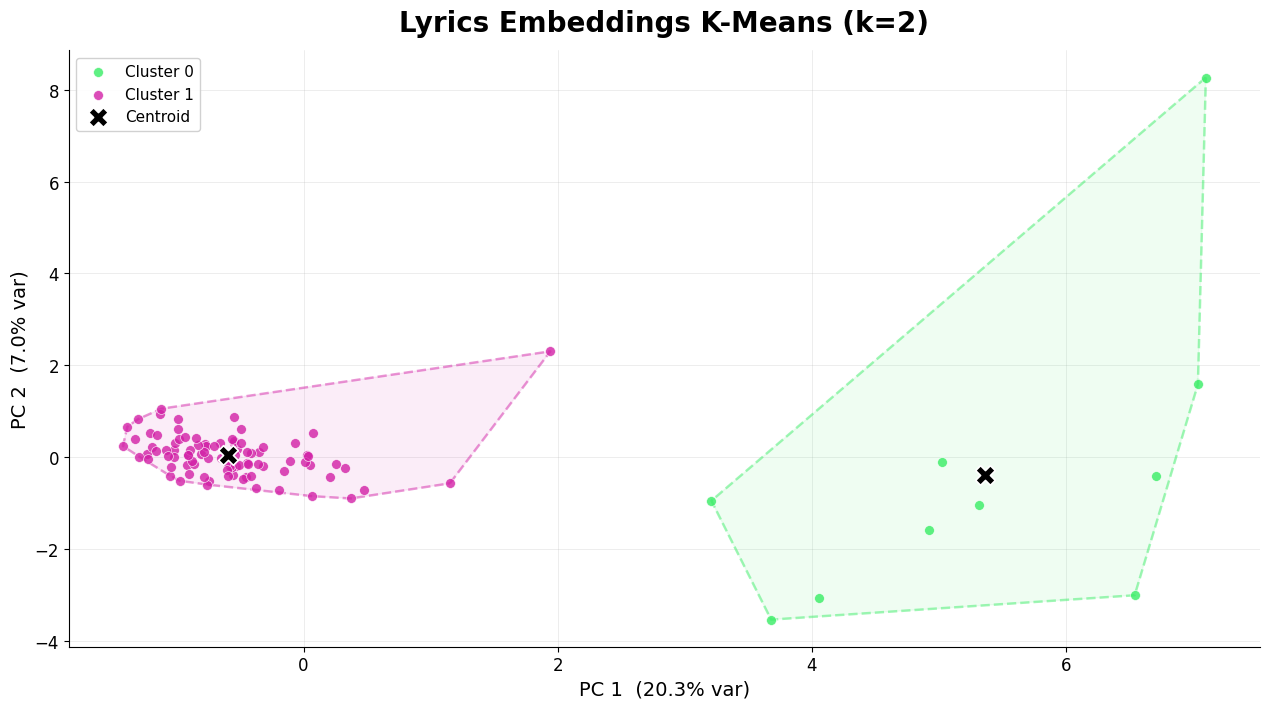

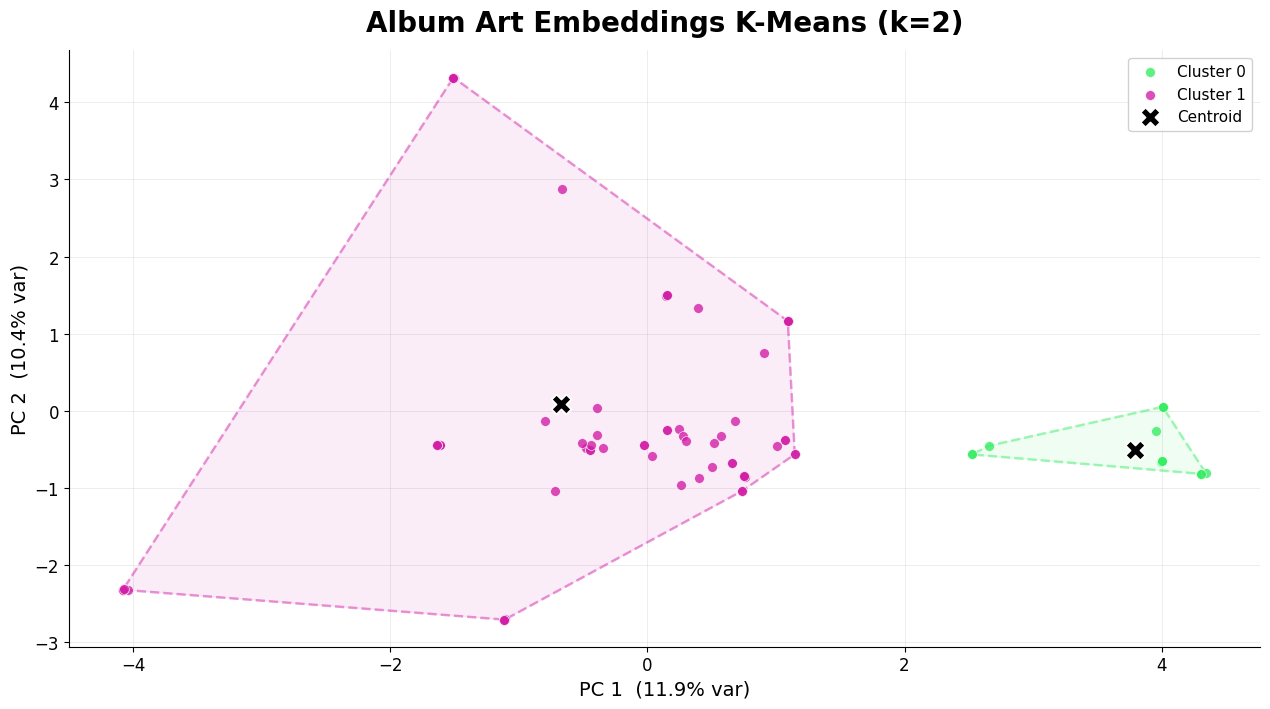

In [38]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

for df_norm, clust, km, title, fname in [
    (df_audio_norm,  audio_clusters,  audio_km,  "Audio Features K-Means (k={})".format(clusters),  "cluster_audio.png"),
    (df_lyrics_norm, lyrics_clusters, lyrics_km, "Lyrics Embeddings K-Means (k={})".format(clusters), "cluster_lyrics.png"),
    (df_image_norm,  image_clusters,  image_km,  "Album Art Embeddings K-Means (k={})".format(clusters), "cluster_image.png"),
]:
    fig, ax = plt.subplots(figsize=(W, H))
    plot_clusters_2d(df_norm, clust, km, title, ax)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()

# Merging Features
Although its cool for us humans to see this data seprately, its much easier for the computer to process if we merge them into one dataset. However, there is one caviat. Not all data features are created equal, although the symantic meaning of the cover is important, the audio features are much more important for a playlist to flow well. 

In [39]:
matrices = [dist_audio, dist_lyrics, dist_image]
weights = [0.7, 0.6, 0.3]

weights = np.array(weights) / np.sum(weights)
scaled = []
for mat in matrices:
    vals = mat.values
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    if hi - lo > 0:
        scaled.append((vals - lo) / (hi - lo))
    else:
        scaled.append(np.zeros_like(vals))
merged_vals = sum(w * s for w, s in zip(weights, scaled))
np.fill_diagonal(merged_vals, np.nan)
dist_merged = pd.DataFrame(merged_vals, index=matrices[0].index, columns=matrices[0].columns)

weighted = [df * w for df, w in zip(matrices, weights)]
merged_features =  pd.concat(weighted, axis=1)

merged_clusters, merged_km = kmeans_cluster(merged_features, n_clusters=clusters)

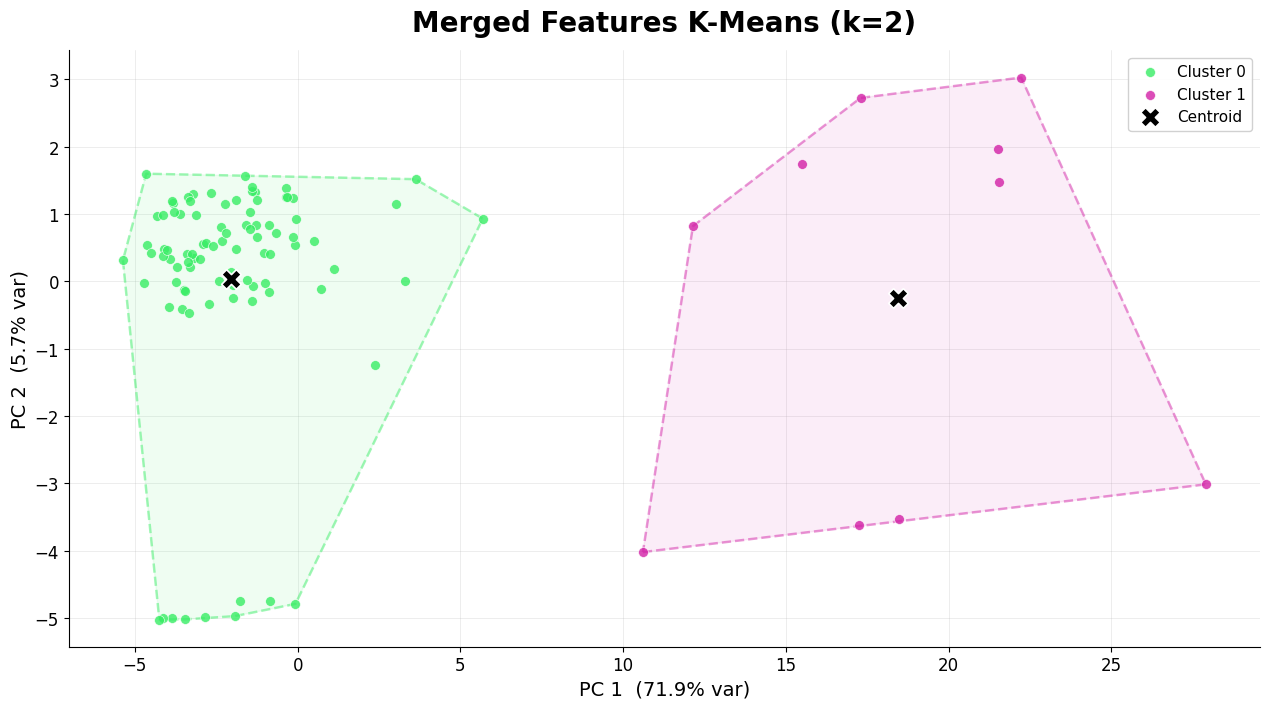

In [40]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

fig, ax = plt.subplots(figsize=(W, H))
plot_clusters_2d(merged_features, merged_clusters, merged_km, "Merged Features K-Means (k={})".format(clusters), ax)
fig.tight_layout()
fig.savefig("cluster_merged.png", dpi=DPI, bbox_inches="tight")
plt.show()

### Experimenting complete, now for the assignment.

# Keys & Tempo
After talking with my friend who DJs, I realized that one of the most important features to transition between songs is the key and tempo. This can quickly get complicated, but keys boil down to a circle of fifths (C to G is closer than C to F#), using this we can calculate the distance between keys. For tempos, we can use the BPM diffrence since songs that are close in tempo are more likely to be smooth transitions (ex. 160 BPM to 162 BPM will flow much better than 160 BPM to 180 BPM). With these two features, once normailzed we can use it as an additional metric to calculate the distance between songs.

In [41]:
circle_of_fifths = {0:0, 7:1, 2:2, 9:3, 4:4, 11:5, 6:6, 1:7, 8:8, 3:9, 10:10, 5:11}

keys = df_audio["key"].fillna(0).astype(int).values
n = len(keys)

key_pos = np.array([circle_of_fifths.get(k, 0) for k in keys])
key_diff = np.abs(key_pos[:, None] - key_pos[None, :])
key_dist = np.minimum(key_diff, 12 - key_diff) / 6.0

tempos = df_audio_norm["tempo"].values
tempo_dist = np.abs(tempos[:, None] - tempos[None, :])
flow_vals = 0.6 * key_dist + 0.4 * tempo_dist
np.fill_diagonal(flow_vals, np.nan)
dist_flow = pd.DataFrame(flow_vals, index=df_audio.index, columns=df_audio.index)

m = dist_merged.values
m_lo, m_hi = np.nanmin(m), np.nanmax(m)
m_scaled = (m - m_lo) / (m_hi - m_lo)
blended = 0.5 * flow_vals + 0.5 * m_scaled
np.fill_diagonal(blended, np.nan)
dist_playlist = pd.DataFrame(blended, index=df_audio.index, columns=df_audio.index)

print(f"Distance Flow  mean: {np.nanmean(dist_flow.values):.4f}")
print(f"Distance Merged mean: {np.nanmean(dist_merged.values):.4f}")
print(f"Distance Playlist mean: {np.nanmean(dist_playlist.values):.4f}")

Distance Flow  mean: 0.3240
Distance Merged mean: 0.5289
Distance Playlist mean: 0.4595


# The smooth playlist

This playlist building method greedily picks a song and then tries to find the closest song that satisfies the constraints.

The constraints are:
- No back-to-back repeats
- No more than 2 songs by the same artist
- No more than 2 songs from the same album

My algorithm works like this:
1. Picks the most central song (lowest average distance to all others).
2. Finds the next closest avaible song that satifies the constraints using the euclidean distances.
   To allow for more variation, amoung artists and albums:
      - I incresed the distance by 0.15 for each artist and album that was already in the playlist.
      - Every 2 steps, I blend 75% flow-closeness with 25% semantic distance to push the listener toward different moods/artists.
   
   If there is a tie on the closest distance between songs, I pick the one whose name comes first alphabetically.
3. After step 2 gets us 6 songs, I optimize the ordering to reduce the total distance to be as small as possible.

In [42]:
avg_dist = dist_playlist.mean(axis=1)
start_song = avg_dist.idxmin()
playlist = [start_song]
selected = {start_song}
artist_penalty_weight = 0.15
variance_every = 2
variance_strength = 0.25
max_variance_flow = 0.25

for step in range(1, 6):
    current = playlist[-1]
    current_artist = artist_series[current]
    distances = dist_playlist.loc[current].copy()

    for sid in selected:
        distances[sid] = np.inf

    for sid in artist_series[artist_series == current_artist].index:
        if sid not in selected:
            distances[sid] = np.inf

    artist_counts = {}
    for sid in playlist:
        a = artist_series[sid]
        artist_counts[a] = artist_counts.get(a, 0) + 1
    for sid in distances.index:
        if distances[sid] < np.inf:
            a = artist_series[sid]
            if a in artist_counts:
                distances[sid] += artist_penalty_weight * artist_counts[a]

    if distances.min() == np.inf:
        distances = dist_playlist.loc[current].copy()
        for sid in selected:
            distances[sid] = np.inf

    if step % variance_every == 0 and distances.min() < max_variance_flow:
        candidates = distances[distances < np.inf].index.tolist()
        if len(candidates) > 1:
            flow_vals_step = distances[candidates].values
            f_min, f_max = flow_vals_step.min(), flow_vals_step.max()
            flow_norm = (flow_vals_step - f_min) / (f_max - f_min) if f_max > f_min else np.zeros(len(candidates))
            flow_closeness = 1.0 - flow_norm

            sem_vals = dist_merged.loc[current, candidates].values
            s_min, s_max = sem_vals.min(), sem_vals.max()
            sem_norm = (sem_vals - s_min) / (s_max - s_min) if s_max > s_min else np.zeros(len(candidates))

            score = (1 - variance_strength) * flow_closeness + variance_strength * sem_norm
            next_song = candidates[np.argmax(score)]
        else:
            min_dist = distances.min()
            tied = distances[distances == min_dist].index.tolist()
            tied.sort(key=lambda s: song_name_series[s].lower())
            next_song = tied[0]
    else:
        min_dist = distances.min()
        tied = distances[distances == min_dist].index.tolist()
        tied.sort(key=lambda s: song_name_series[s].lower())
        next_song = tied[0]

    playlist.append(next_song)
    selected.add(next_song)

for i, sid in enumerate(playlist):
    print(f"  S{i}: {song_name_series[sid]} by {artist_series[sid]}")

  S0: King Of My Heart by ['Taylor Swift']
  S1: Happier by ['Ed Sheeran']
  S2: Roller Coaster by ['Luke Bryan']
  S3: Growing Up (feat. Ed Sheeran) by ['Macklemore & Ryan Lewis', 'Macklemore', 'Ryan Lewis', 'Ed Sheeran']
  S4: Before I Let Go - Homecoming Live Bonus Track by ['Beyoncé']
  S5: River (feat. Ed Sheeran) by ['Eminem', 'Ed Sheeran']


# Question 1's Solution
The playlist of songs with the computed distances to make a smooth transition

In [43]:
route = list(playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True
playlist = route


features = df_audio_norm.columns.tolist()
rows = []
for i, sid in enumerate(playlist):
    row = {"Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "-"
        row["Audio Dist"] = "-"
        row["Lyrics Dist"] = "-"
        row["Image Dist"] = "-"
        row["Merged Dist"] = "-"
        row["Blended Dist"] = "-"
    rows.append(row)

display(pd.DataFrame(rows))

,Song,Artist,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,...,mode_confidence,song_duration_ms,popularity,explicit,Flow Dist,Audio Dist,Lyrics Dist,Image Dist,Merged Dist,Blended Dist
0,King Of My Heart,['Taylor Swift'],0.427,0.709,0.871,0.518,0.900,0.752,0.737,0.000,...,0.562,0.265,0.673,0.000,-,-,-,-,-,-
1,Happier,['Ed Sheeran'],0.389,0.732,0.950,0.580,0.900,0.632,0.771,0.000,...,0.750,0.236,0.727,0.000,0.0000,0.6232,3.8817,8.0486,0.3090,0.1535
2,Roller Coaster,['Luke Bryan'],0.599,0.709,0.582,0.448,0.900,0.752,0.363,0.000,...,0.500,0.450,0.564,0.000,0.0000,0.9492,5.0461,9.5412,0.4148,0.2228
3,Growing Up (feat. Ed Sheeran),"['Macklemore & Ryan Lewis', 'Macklemore', 'Rya...",0.212,0.863,0.731,0.736,0.900,0.247,0.829,0.000,...,0.625,0.641,0.327,0.000,0.0373,1.0033,4.1310,9.5632,0.3971,0.2298
4,Before I Let Go - Homecoming Live Bonus Track,['Beyoncé'],0.152,0.853,0.915,0.671,0.900,0.331,0.546,0.000,...,0.688,0.374,0.382,1.000,0.0000,1.2164,3.8894,9.0595,0.4128,0.2215
5,River (feat. Ed Sheeran),"['Eminem', 'Ed Sheeran']",0.074,0.936,0.801,0.799,0.900,0.098,0.685,0.000,...,0.500,0.292,0.691,1.000,0.0210,0.5758,4.2871,9.0869,0.3311,0.1785


# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [44]:
consec = list(range(len(playlist) - 1))
flow_d = [dist_flow.loc[playlist[i], playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[playlist[i], playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in consec]
image_d = [dist_image.loc[playlist[i], playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[playlist[i], playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in consec]

from itertools import combinations

all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]
unique_artists = list(set(artist_series[sid] for sid in playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.0116  (deviation: 0.0152, max: 0.0373)
  Audio:   0.8736  (deviation: 0.2414)
  Lyrics:  4.2471  (deviation: 0.4278)
  Image:   9.0599  (deviation: 0.5493)
  Merged:  0.3730  (deviation: 0.0442)
  Blended: 0.2012  (deviation: 0.0300)
Semantic spread: 0.4042
Artist diversity: 6 unique


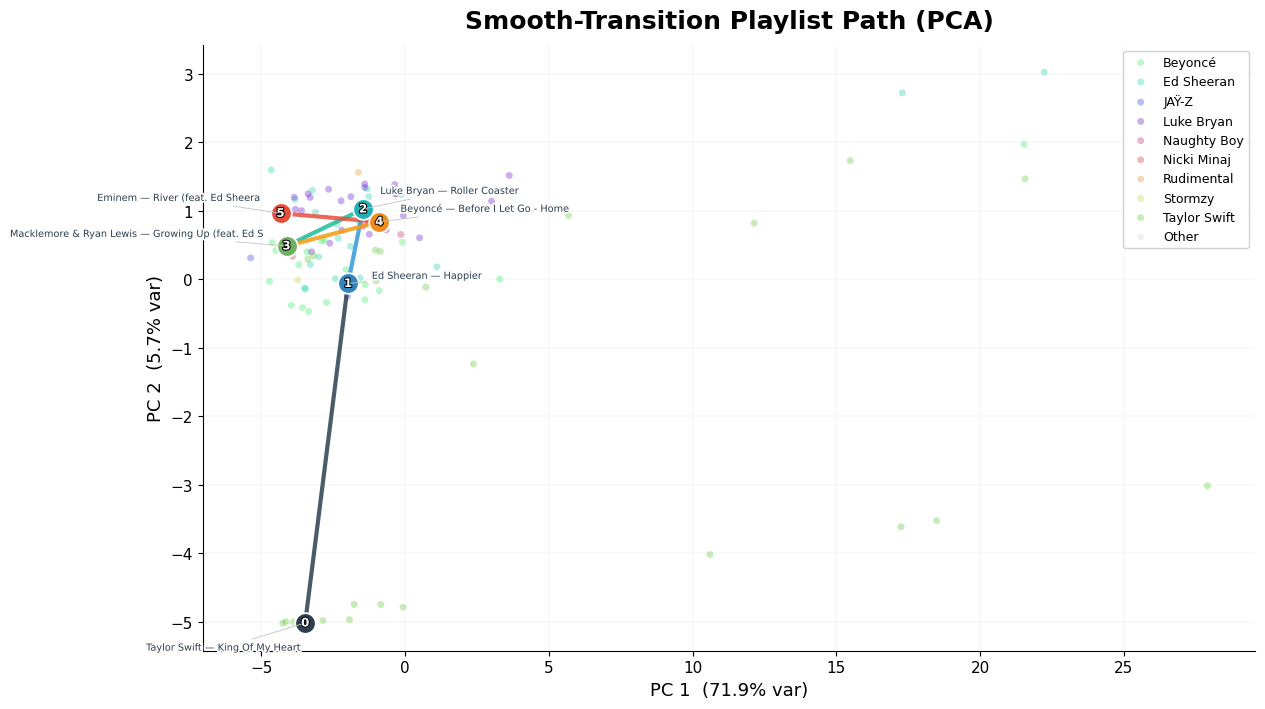

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': 'Smooth-Transition Playlist Path (PCA)'}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [45]:
from graphing_graphics import plot_smooth_playlist, primary_artist, _generate_distinct_colors

unique_artists = sorted(set(artist_series.map(primary_artist)))
artist_colors = dict(zip(unique_artists, _generate_distinct_colors(len(unique_artists))))

plot_smooth_playlist(
    merged_features, playlist, artist_series, song_name_series,
    artist_colors=artist_colors,
)

# The thematic playlist

Similar to the last playlist, we're making a playlist using shortest euclidean distances. Instead we'll use a simple k means clustering approch to divide the songs into groups of similar songs and then picks one central song from each cluster.

1. Use k means clustering to divide the songs into groups of similar songs.
    Why did I pick k=6? Since the playlist needs to be 6 songs long, we need exactly 6 songs for the playlist. Using 6 clusters means each cluster contributes one song, guaranteeing the playlist spans the every possible thematic region of the dataset.
2. From each cluster, I score each song based on how close it is to the cluster's centroid (weighted at 60%) and bridge quality (how close it is to other clusters' centroids). This means that every song I pick is both representative of its cluster and a good transition point to other clusters.
3. I then order the playlist of the 6 representatives using greedy nearest neighbors.
4. Copied the post-refinement and forward vs reversed steps from the last playlist generation method.

In [46]:
thematic_k = 6
thematic_clusters, thematic_km = kmeans_cluster(merged_features, n_clusters=thematic_k)

print(f"Cluster sizes:")
for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index
    artists_in = artist_series[members].value_counts()
    print(f"  Cluster {cid}: {len(members)} songs")

Cluster sizes:
  Cluster 0: 32 songs
  Cluster 1: 6 songs
  Cluster 2: 9 songs
  Cluster 3: 4 songs
  Cluster 4: 40 songs
  Cluster 5: 9 songs


# Question 2's solution
The thematic playlist using k means clustering

In [47]:
from graphing_graphics import primary_artist

filled = merged_features.fillna(merged_features.median())
centroids = thematic_km.cluster_centers_

# Build scored candidate lists per cluster (sorted best-first)
cluster_ranked = {}  # cid -> [(sid, combined_score), ...]
for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index.tolist()
    scores = []
    for sid in members:
        d_own = np.linalg.norm(filled.loc[sid].values - centroids[cid])
        d_others = [np.linalg.norm(filled.loc[sid].values - centroids[c]) for c in range(thematic_k) if c != cid]
        d_bridge = np.mean(d_others)
        scores.append((sid, d_own, d_bridge))

    own_vals = np.array([s[1] for s in scores])
    bridge_vals = np.array([s[2] for s in scores])
    own_norm = (own_vals - own_vals.min()) / (own_vals.max() - own_vals.min()) if own_vals.max() > own_vals.min() else np.zeros(len(scores))
    bridge_norm = (bridge_vals - bridge_vals.min()) / (bridge_vals.max() - bridge_vals.min()) if bridge_vals.max() > bridge_vals.min() else np.zeros(len(scores))

    combined = 0.6 * own_norm + 0.4 * bridge_norm
    ranked = sorted(zip([s[0] for s in scores], combined), key=lambda x: x[1])
    cluster_ranked[cid] = ranked

# Initial pick: best representative per cluster
representatives = [cluster_ranked[cid][0][0] for cid in range(thematic_k)]

# Enforce artist constraint: every required artist must appear at least once
required_artists = {'Beyonce', 'Ed Sheeran', 'Luke Bryan', 'Taylor Swift'}
# Normalise for comparison (handle accented chars)
def _pa(sid):
    return primary_artist(artist_series[sid]).replace('\u00e9', 'e')

present = {_pa(sid) for sid in representatives}
missing = {a for a in required_artists if a not in present}

# For each missing artist, find the cheapest cluster swap
for needed_artist in missing:
    best_swap = None  # (cost_delta, cluster_id, new_sid)
    for cid in range(thematic_k):
        current_rep = representatives[cid]
        current_score = dict(cluster_ranked[cid])[current_rep]
        # Only swap a cluster whose current rep is NOT the sole provider of another required artist
        current_rep_artist = _pa(current_rep)
        other_reps_artists = {_pa(representatives[c]) for c in range(thematic_k) if c != cid}
        if current_rep_artist in required_artists and current_rep_artist not in other_reps_artists:
            continue  # swapping would remove the only provider of another required artist
        # Find best candidate in this cluster with the needed artist
        for sid, score in cluster_ranked[cid]:
            if _pa(sid) == needed_artist:
                cost_delta = score - current_score
                if best_swap is None or cost_delta < best_swap[0]:
                    best_swap = (cost_delta, cid, sid)
                break  # first match is already the best-scored for this artist in this cluster
    if best_swap is not None:
        _, swap_cid, swap_sid = best_swap
        representatives[swap_cid] = swap_sid
        present = {_pa(sid) for sid in representatives}  # refresh

print(f"Representatives cover artists: {sorted({_pa(s) for s in representatives})}")

avg_d = dist_playlist.loc[representatives, representatives].mean(axis=1)
current = avg_d.idxmin()
thematic_playlist = [current]
remaining = set(representatives) - {current}

for step in range(1, 6):
    current = thematic_playlist[-1]
    current_artist = artist_series[current]

    diff_artist = [s for s in remaining if artist_series[s] != current_artist]
    pool = diff_artist if diff_artist else list(remaining)
    distances = dist_playlist.loc[current, pool].copy()

    min_dist = distances.min()
    tied = distances[distances == min_dist].index.tolist()
    tied.sort(key=lambda s: song_name_series[s].lower())
    next_song = tied[0]

    thematic_playlist.append(next_song)
    remaining.remove(next_song)

route = list(thematic_playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True

thematic_playlist = route
fwd_cost = sum(dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in range(len(thematic_playlist)-1))
rev = list(reversed(thematic_playlist))
rev_ok = all(artist_series[rev[k]] != artist_series[rev[k+1]] for k in range(len(rev)-1))
if rev_ok:
    rev_cost = sum(dist_playlist.loc[rev[i], rev[i+1]] for i in range(len(rev)-1))
    if rev_cost < fwd_cost:
        thematic_playlist = rev


features = df_audio_norm.columns.tolist()
rows = []
for i, sid in enumerate(thematic_playlist):
    row = {"Cluster": thematic_clusters[sid],
           "Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = thematic_playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "-"
        row["Audio Dist"] = "-"
        row["Lyrics Dist"] = "-"
        row["Image Dist"] = "-"
        row["Merged Dist"] = "-"
        row["Blended Dist"] = "-"
    rows.append(row)

display(pd.DataFrame(rows))

Representatives cover artists: ['Beyonce', 'Ed Sheeran', 'JAŸ-Z', 'Luke Bryan', 'Taylor Swift']


,Cluster,Song,Artist,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,...,mode_confidence,song_duration_ms,popularity,explicit,Flow Dist,Audio Dist,Lyrics Dist,Image Dist,Merged Dist,Blended Dist
0,2,Daylight,['Taylor Swift'],0.931,0.528,0.119,0.773,0.000,1.000,0.167,...,0.625,0.592,0.836,0.000,-,-,-,-,-,-
1,4,Shape of You,['Ed Sheeran'],0.196,0.378,0.697,0.798,0.700,0.175,0.730,...,0.500,0.345,1.000,0.000,0.3150,1.9345,4.8094,8.0702,0.5271,0.4539
2,3,Don’t Blame Me,['Taylor Swift'],0.442,0.896,0.856,0.457,0.000,0.908,0.505,...,0.625,0.356,0.873,0.000,0.2519,1.4380,8.1702,8.9044,0.5643,0.4467
3,1,Best Thing I Never Had,['Beyoncé'],0.152,0.853,0.915,0.671,0.900,0.331,0.546,...,0.688,0.428,0.582,0.000,0.3438,1.6528,10.8174,7.9944,0.6556,0.5524
4,5,Lift Off,"['JAŸ-Z', 'Kanye West', 'Beyoncé']",0.643,0.358,0.552,0.843,0.900,0.647,0.498,...,0.688,0.480,0.382,1.000,0.0694,1.5182,10.8570,8.5774,0.6469,0.4095
5,0,"Sunrise, Sunburn, Sunset",['Luke Bryan'],0.397,0.485,0.677,0.891,0.400,0.499,0.049,...,0.250,0.272,0.473,0.000,0.1155,1.9179,5.3854,8.6550,0.5509,0.3697


# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [48]:
consec = list(range(len(thematic_playlist) - 1))
flow_d = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
image_d = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]

from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in thematic_playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.2191  (deviation: 0.1086, max: 0.3438)
  Audio:   1.6923  (deviation: 0.2030)
  Lyrics:  8.0079  (deviation: 2.5747)
  Image:   8.4403  (deviation: 0.3510)
  Merged:  0.5890  (deviation: 0.0523)
  Blended: 0.4464  (deviation: 0.0609)
Semantic spread: 0.5832
Artist diversity: 5 unique


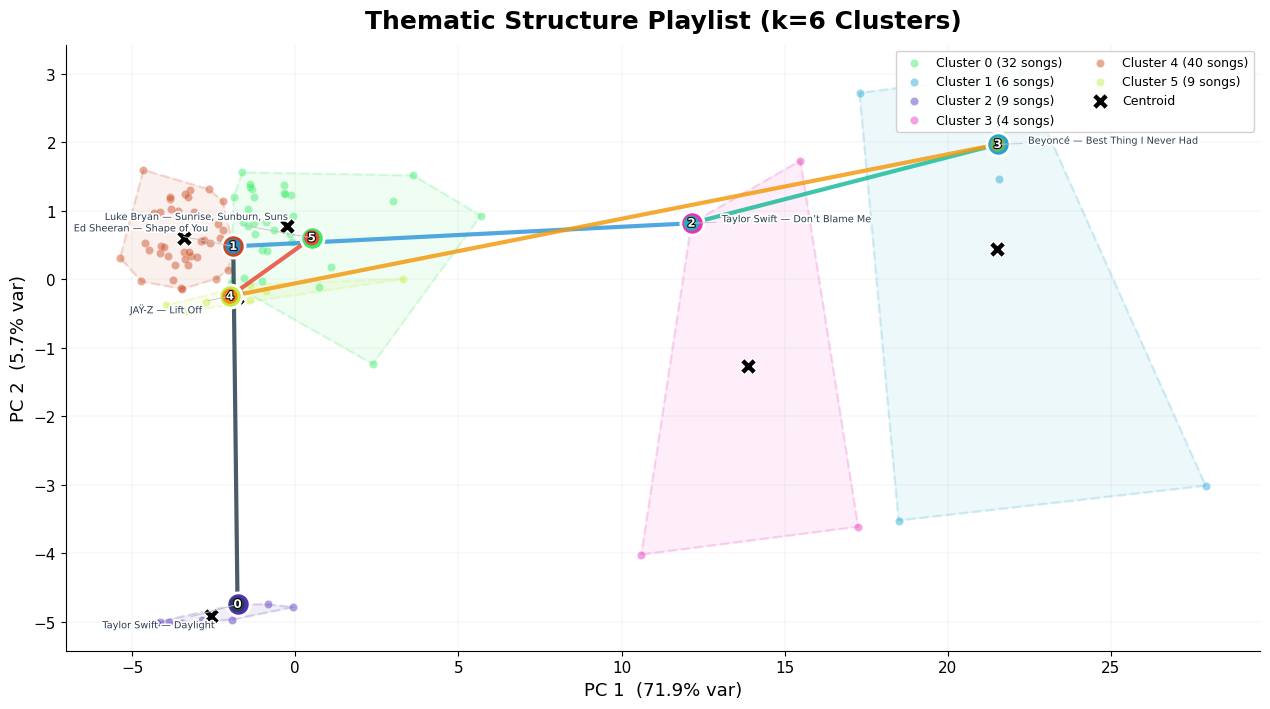

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': 'Thematic Structure Playlist (k=6 Clusters)'}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [49]:
from graphing_graphics import plot_thematic_playlist

plot_thematic_playlist(
    merged_features, thematic_playlist, thematic_clusters, thematic_km,
    artist_series, song_name_series,
)

# Alice's Random Playlist (Control)

Ignoring all features and distances and randomly picking songs with rules:

- At least one song from each artist
- 6 songs max

In [50]:
from graphing_graphics import primary_artist

rng = np.random.default_rng(seed=42)

primary = artist_series.map(primary_artist)
major_artists = primary.value_counts().nlargest(4).index.tolist()

alice_picks = []
for artist in major_artists:
    pool = primary[primary == artist].index.tolist()
    alice_picks.append(rng.choice(pool))

remaining_pool = [s for s in primary.index if s not in alice_picks]
extras = rng.choice(remaining_pool, size=2, replace=False)
alice_picks.extend(extras.tolist())

rng.shuffle(alice_picks)
alice_playlist = alice_picks



features = df_audio_norm.columns.tolist()
rows = []
for i, sid in enumerate(alice_playlist):
    row = {"Cluster": thematic_clusters[sid],
           "Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = alice_playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "-"
        row["Audio Dist"] = "-"
        row["Lyrics Dist"] = "-"
        row["Image Dist"] = "-"
        row["Merged Dist"] = "-"
        row["Blended Dist"] = "-"
    rows.append(row)

display(pd.DataFrame(rows))

,Cluster,Song,Artist,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,...,mode_confidence,song_duration_ms,popularity,explicit,Flow Dist,Audio Dist,Lyrics Dist,Image Dist,Merged Dist,Blended Dist
0,2,King Of My Heart,['Taylor Swift'],0.427,0.709,0.871,0.518,0.900,0.752,0.737,...,0.562,0.265,0.673,0.000,-,-,-,-,-,-
1,5,Haunted,['Beyoncé'],0.935,0.686,0.060,0.588,0.900,1.000,0.000,...,0.625,0.905,0.745,1.000,0.0810,2.1224,3.0550,8.1096,0.5053,0.3226
2,4,Afire Love,['Ed Sheeran'],0.266,0.241,0.836,0.116,0.500,0.483,0.848,...,0.750,0.679,0.400,0.000,0.5930,2.8909,3.8143,8.8672,0.6518,0.6745
3,4,Move,['Luke Bryan'],0.826,0.702,0.294,0.493,0.000,1.000,0.231,...,0.625,0.319,0.473,0.000,0.3368,1.8716,3.7312,8.8511,0.5004,0.4472
4,0,Cruel Summer,['Taylor Swift'],0.591,0.569,0.617,0.153,0.900,0.945,0.625,...,0.562,0.116,0.982,0.000,0.3539,1.7650,5.1471,8.7708,0.5238,0.4711
5,4,Dive,['Ed Sheeran'],0.614,0.455,0.592,0.470,0.900,0.867,0.658,...,0.688,0.364,0.745,0.000,0.0300,1.0579,5.7719,8.2832,0.4302,0.2478


# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [51]:
consec = list(range(len(alice_playlist) - 1))
flow_d = [dist_flow.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
image_d = [dist_image.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]

from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(alice_playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in alice_playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.2789  (deviation: 0.2043, max: 0.5930)
  Audio:   1.9416  (deviation: 0.5918)
  Lyrics:  4.3039  (deviation: 0.9994)
  Image:   8.5764  (deviation: 0.3168)
  Merged:  0.5223  (deviation: 0.0721)
  Blended: 0.4326  (deviation: 0.1459)
Semantic spread: 0.4990
Artist diversity: 4 unique


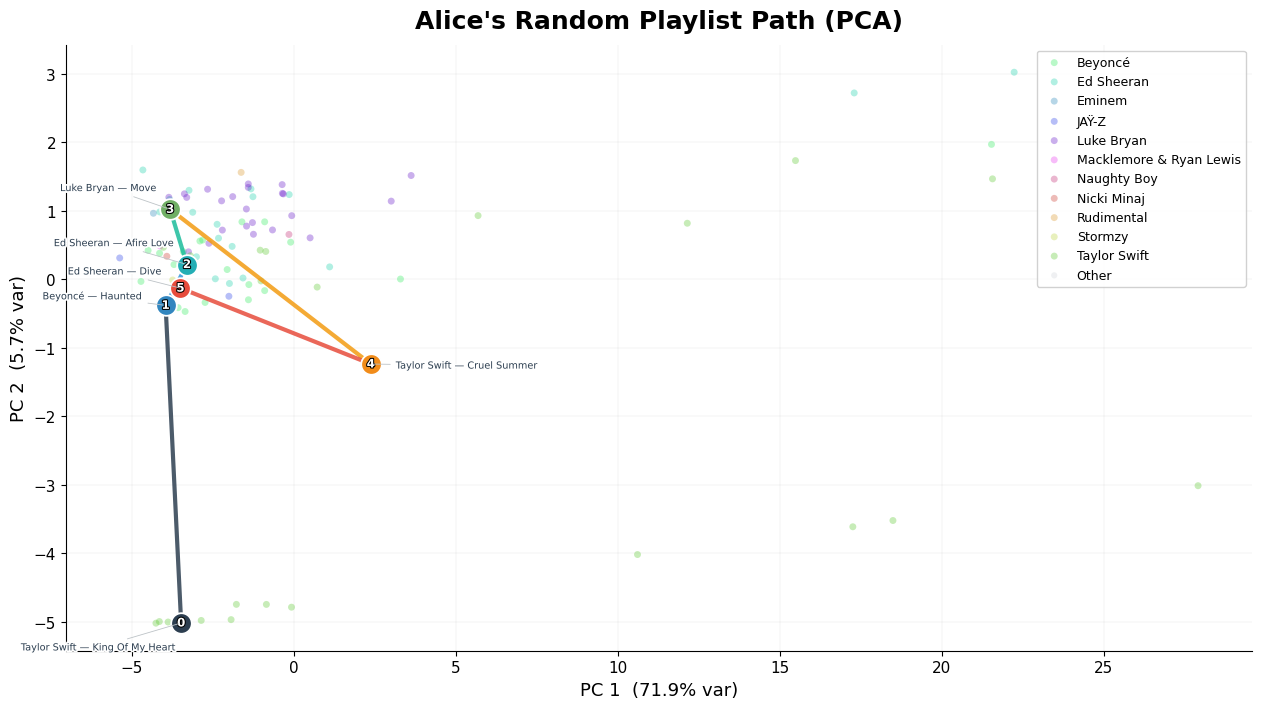

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': "Alice's Random Playlist Path (PCA)"}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [52]:
from graphing_graphics import plot_smooth_playlist, primary_artist, _generate_distinct_colors

unique_artists = sorted(set(artist_series.map(primary_artist)))
artist_colors = dict(zip(unique_artists, _generate_distinct_colors(len(unique_artists))))

plot_smooth_playlist(
    merged_features, alice_playlist, artist_series, song_name_series,
    artist_colors=artist_colors,
    title="Alice's Random Playlist Path (PCA)",
    save_path="random_playlist_path.png",
)

In [53]:
s_consec = list(range(len(playlist) - 1))
s_flow = [dist_flow.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_audio = [dist_audio.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_lyrics = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_image = [dist_image.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_merged = [dist_merged.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_blended = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_pairs = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]
s_artists = list(set(artist_series[sid] for sid in playlist))

t_consec = list(range(len(thematic_playlist) - 1))
t_flow = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_audio = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_lyrics = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_image = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_merged = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_blended = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_pairs = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]
t_artists = list(set(artist_series[sid] for sid in thematic_playlist))

a_consec = list(range(len(alice_playlist) - 1))
a_flow = [dist_flow.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_audio = [dist_audio.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_lyrics = [dist_lyrics.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_image = [dist_image.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_merged = [dist_merged.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_blended = [dist_playlist.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_pairs = [dist_merged.loc[a, b] for a, b in combinations(alice_playlist, 2)]
a_artists = list(set(artist_series[sid] for sid in alice_playlist))

comparison = pd.DataFrame({
    "Metric": [
        "Mean Flow Dist", "Max Flow Dist", "Deviation Flow Dist",
        "Mean Audio Dist", "Mean Lyrics Dist", "Mean Image Dist",
        "Mean Merged Dist", "Mean Blended Dist",
        "Semantic Spread", "Unique Artists"
    ],
    "Smooth Transition": [
        f"{np.mean(s_flow):.4f}", f"{max(s_flow):.4f}", f"{np.std(s_flow):.4f}",
        f"{np.mean(s_audio):.4f}", f"{np.mean(s_lyrics):.4f}", f"{np.mean(s_image):.4f}",
        f"{np.mean(s_merged):.4f}", f"{np.mean(s_blended):.4f}",
        f"{np.mean(s_pairs):.4f}", f"{len(s_artists)}"
    ],
    "Thematic Structure": [
        f"{np.mean(t_flow):.4f}", f"{max(t_flow):.4f}", f"{np.std(t_flow):.4f}",
        f"{np.mean(t_audio):.4f}", f"{np.mean(t_lyrics):.4f}", f"{np.mean(t_image):.4f}",
        f"{np.mean(t_merged):.4f}", f"{np.mean(t_blended):.4f}",
        f"{np.mean(t_pairs):.4f}", f"{len(t_artists)}"
    ],
    "Alice's Random": [
        f"{np.mean(a_flow):.4f}", f"{max(a_flow):.4f}", f"{np.std(a_flow):.4f}",
        f"{np.mean(a_audio):.4f}", f"{np.mean(a_lyrics):.4f}", f"{np.mean(a_image):.4f}",
        f"{np.mean(a_merged):.4f}", f"{np.mean(a_blended):.4f}",
        f"{np.mean(a_pairs):.4f}", f"{len(a_artists)}"
    ]
})
display(comparison)

,Metric,Smooth Transition,Thematic Structure,Alice's Random
0,Mean Flow Dist,0.0116,0.2191,0.2789
1,Max Flow Dist,0.0373,0.3438,0.5930
2,Deviation Flow Dist,0.0152,0.1086,0.2043
3,Mean Audio Dist,0.8736,1.6923,1.9416
4,Mean Lyrics Dist,4.2471,8.0079,4.3039
5,Mean Image Dist,9.0599,8.4403,8.5764
6,Mean Merged Dist,0.3730,0.5890,0.5223
7,Mean Blended Dist,0.2012,0.4464,0.4326
8,Semantic Spread,0.4042,0.5832,0.4990
9,Unique Artists,6,5,4


# Base Features vs Extended Features Comparison

All the playlist work above relied on the **extended** dataset produced by `Class DB Expansion.ipynb`, which enriched each track with:
- Additional Spotify audio-analysis features (fade-in/out, time-signature & key & mode & tempo confidence, num_samples, duration)
- 768-dimensional **lyrics embeddings** (semantic meaning of lyrics)
- 768-dimensional **album-art image embeddings** (visual style of cover art)

To check whether that expansion was actually worth the effort, we now re-run the **same two playlist algorithms** using only the **14 numeric base features** that were already present in the original `Songs.csv`:

> `danceability, energy, valence, tempo, loudness, mode, key, acousticness, instrumentalness, liveness, speechiness, explicit, duration_ms, popularity`

If the two base-only playlists score similarly on the same metrics, the expansion added little value. If the extended playlists score noticeably better (lower distances, higher spread), the expansion was worthwhile.

In [54]:
# ── Load Songs.csv and align its rows to the song_id index used throughout ──
import ast

BASE_FEATURES = [
    "danceability", "energy", "valence", "tempo", "loudness",
    "mode", "key", "acousticness", "instrumentalness",
    "liveness", "speechiness", "explicit", "duration_ms", "popularity"
]

df_base_raw = pd.read_csv("Songs.csv")

# Build a lookup: (normalised_title, primary_artist) -> base-feature row
def _norm(s):
    # Normalise curly/smart apostrophes to straight ones before lowercasing
    return str(s).strip().replace("\u2019", "'").replace("\u2018", "'").lower()

def _primary(artists_str):
    try:
        lst = ast.literal_eval(artists_str)
        return _norm(lst[0]) if lst else ""
    except Exception:
        return _norm(artists_str)

base_lookup = {}
for _, row in df_base_raw.iterrows():
    key = (_norm(row["song_title (censored)"]), _primary(row["artist_names"]))
    base_lookup[key] = row

# Map each song_id (from the extended dataset) to its base-feature row
matched_ids   = []
missed_titles = []
base_rows     = []

for sid in df_audio.index:
    title  = _norm(song_name_series[sid])
    artist = _norm(str(artist_series[sid]))
    # Try exact (title, first-artist) key first
    primary_a = _primary(str(artist_series[sid]))
    row = base_lookup.get((title, primary_a))
    if row is None:
        # Fallback: match on title alone
        candidates = [v for (t, a), v in base_lookup.items() if t == title]
        row = candidates[0] if candidates else None
    if row is not None:
        matched_ids.append(sid)
        base_rows.append(row[BASE_FEATURES].values.astype(float))
    else:
        missed_titles.append(song_name_series[sid])

df_base = pd.DataFrame(
    base_rows,
    index=pd.Index(matched_ids, name="song_id"),
    columns=BASE_FEATURES
)

print(f"Matched {len(matched_ids)} / {len(df_audio)} songs to Songs.csv")
if missed_titles:
    print(f"Unmatched ({len(missed_titles)}): {missed_titles}")

# Normalise and compute distance matrix
df_base_norm  = normalize_df(df_base)
dist_base_audio = euclidean_distance_matrix(df_base_norm)

print(f"\nBase features only:")
print(f"  Shape:            {df_base.shape}")
print(f"  Normalised range: {df_base_norm.min().min():.4f} to {df_base_norm.max().max():.4f}")
print(f"  Distance matrix:  {dist_base_audio.shape}")
print(f"  Mean distance:    {dist_base_audio.values[np.triu_indices_from(dist_base_audio.values, k=1)].mean():.4f}")

Matched 100 / 100 songs to Songs.csv

Base features only:
  Shape:            (100, 14)
  Normalised range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    1.3259


In [55]:
# ── Build flow distance and blended playlist distance (base features only) ──

keys_base   = df_base["key"].fillna(0).astype(int).values
key_pos_b   = np.array([circle_of_fifths.get(k, 0) for k in keys_base])
key_diff_b  = np.abs(key_pos_b[:, None] - key_pos_b[None, :])
key_dist_b  = np.minimum(key_diff_b, 12 - key_diff_b) / 6.0

tempos_base  = df_base_norm["tempo"].values
tempo_dist_b = np.abs(tempos_base[:, None] - tempos_base[None, :])

flow_vals_b = 0.6 * key_dist_b + 0.4 * tempo_dist_b
np.fill_diagonal(flow_vals_b, np.nan)
dist_flow_base = pd.DataFrame(flow_vals_b, index=df_base.index, columns=df_base.index)

# Blended distance: 50% flow + 50% normalised base-audio distance
m_b = dist_base_audio.values.copy()
m_b_lo, m_b_hi = np.nanmin(m_b), np.nanmax(m_b)
m_b_scaled = (m_b - m_b_lo) / (m_b_hi - m_b_lo)
blended_b = 0.5 * flow_vals_b + 0.5 * m_b_scaled
np.fill_diagonal(blended_b, np.nan)
dist_playlist_base = pd.DataFrame(blended_b, index=df_base.index, columns=df_base.index)

print(f"Distance Flow (base)    mean: {np.nanmean(dist_flow_base.values):.4f}")
print(f"Distance Audio (base)   mean: {np.nanmean(dist_base_audio.values):.4f}")
print(f"Distance Playlist (base) mean: {np.nanmean(dist_playlist_base.values):.4f}")

Distance Flow (base)    mean: 0.4214
Distance Audio (base)   mean: 1.3259
Distance Playlist (base) mean: 0.4554


## Smooth Transition Playlist — Base Features Only
Same greedy nearest-neighbour algorithm with the same artist-penalty rules, but driven purely by the 14 base numeric features and the circle-of-fifths flow distance.

In [56]:
# ── Smooth playlist — base features ─────────────────────────────────────────
avg_dist_b = dist_playlist_base.mean(axis=1)
start_b    = avg_dist_b.idxmin()
playlist_base = [start_b]
selected_b    = {start_b}

for step in range(1, 6):
    current_b = playlist_base[-1]
    current_artist_b = artist_series[current_b]
    distances_b = dist_playlist_base.loc[current_b].copy()

    for sid in selected_b:
        distances_b[sid] = np.inf
    for sid in artist_series[artist_series == current_artist_b].index:
        if sid not in selected_b:
            distances_b[sid] = np.inf

    artist_counts_b = {}
    for sid in playlist_base:
        a = artist_series[sid]
        artist_counts_b[a] = artist_counts_b.get(a, 0) + 1
    for sid in distances_b.index:
        if distances_b[sid] < np.inf:
            a = artist_series[sid]
            if a in artist_counts_b:
                distances_b[sid] += artist_penalty_weight * artist_counts_b[a]

    if distances_b.min() == np.inf:
        distances_b = dist_playlist_base.loc[current_b].copy()
        for sid in selected_b:
            distances_b[sid] = np.inf

    min_dist_b = distances_b.min()
    tied_b     = distances_b[distances_b == min_dist_b].index.tolist()
    tied_b.sort(key=lambda s: song_name_series[s].lower())
    next_b     = tied_b[0]

    playlist_base.append(next_b)
    selected_b.add(next_b)

# 2-opt refinement
route_b   = list(playlist_base)
n_b       = len(route_b)
improved_b = True
iters_b    = 0
while improved_b and iters_b < 50:
    improved_b = False
    iters_b   += 1
    for i in range(n_b - 2):
        for j in range(i + 2, n_b):
            old_cost = dist_playlist_base.loc[route_b[i], route_b[i + 1]]
            if j + 1 < n_b:
                old_cost += dist_playlist_base.loc[route_b[j], route_b[j + 1]]
            new_cost = dist_playlist_base.loc[route_b[i], route_b[j]]
            if j + 1 < n_b:
                new_cost += dist_playlist_base.loc[route_b[i + 1], route_b[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route_b[:i+1] + route_b[i+1:j+1][::-1] + route_b[j+1:]
                artist_ok = all(
                    artist_series[candidate[k]] != artist_series[candidate[k+1]]
                    for k in range(len(candidate) - 1)
                )
                if artist_ok:
                    route_b    = candidate
                    improved_b = True
playlist_base = route_b

# Display
rows_b = []
for i, sid in enumerate(playlist_base):
    row = {"Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in BASE_FEATURES:
        row[f] = f"{df_base_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = playlist_base[i - 1]
        row["Flow Dist"]  = f"{dist_flow_base.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_base_audio.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist_base.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = row["Audio Dist"] = row["Blended Dist"] = "-"
    rows_b.append(row)
display(pd.DataFrame(rows_b))

,Song,Artist,danceability,energy,valence,tempo,loudness,mode,key,acousticness,instrumentalness,liveness,speechiness,explicit,duration_ms,popularity,Flow Dist,Audio Dist,Blended Dist
0,Afterglow,['Taylor Swift'],0.789,0.366,0.404,0.383,0.380,1.000,0.818,0.132,0.000,0.085,0.023,0.000,0.302,0.615,-,-,-
1,How Would You Feel (Paean),['Ed Sheeran'],0.580,0.353,0.228,0.644,0.621,1.000,0.818,0.435,0.000,0.099,0.007,0.000,0.539,0.564,0.1045,0.5933,0.1246
2,All Night,['Beyoncé'],0.516,0.518,0.658,0.611,0.509,1.000,1.000,0.402,0.000,0.063,0.125,0.000,0.710,0.513,0.2133,0.5580,0.1707
3,Play It Again,['Luke Bryan'],0.414,0.902,0.623,0.680,0.806,1.000,1.000,0.092,0.000,0.042,0.085,0.000,0.317,0.744,0.0275,0.7476,0.1225
4,Runnin' (Lose It All),"['Naughty Boy', 'Beyoncé', 'Arrow Benjamin']",0.133,0.853,0.044,0.637,0.584,1.000,0.545,0.008,0.000,0.471,0.114,0.000,0.259,0.513,0.1172,0.9606,0.2174
5,Lay It All on Me (feat. Ed Sheeran),"['Rudimental', 'Ed Sheeran']",0.658,0.731,0.498,0.487,0.507,1.000,0.545,0.143,0.000,0.161,0.040,0.000,0.381,0.154,0.0600,0.8875,0.1716


In [57]:
# ── Stats for base smooth playlist ──────────────────────────────────────────
from itertools import combinations

consec_b  = list(range(len(playlist_base) - 1))
bs_flow   = [dist_flow_base.loc[playlist_base[i], playlist_base[i+1]]    for i in consec_b]
bs_audio  = [dist_base_audio.loc[playlist_base[i], playlist_base[i+1]]   for i in consec_b]
# Also measure on extended-feature axes for apples-to-apples comparison
bs_lyrics = [dist_lyrics.loc[playlist_base[i], playlist_base[i+1]]       for i in consec_b]
bs_image  = [dist_image.loc[playlist_base[i], playlist_base[i+1]]        for i in consec_b]
bs_merged = [dist_merged.loc[playlist_base[i], playlist_base[i+1]]       for i in consec_b]
bs_blended= [dist_playlist_base.loc[playlist_base[i], playlist_base[i+1]] for i in consec_b]

bs_pairs   = [dist_merged.loc[a, b] for a, b in combinations(playlist_base, 2)]
bs_artists = list(set(artist_series[sid] for sid in playlist_base))

print("Smooth Transition (Base Features Only):")
print(f"  Flow:    {np.mean(bs_flow):.4f}  (deviation: {np.std(bs_flow):.4f}, max: {max(bs_flow):.4f})")
print(f"  Audio (base):   {np.mean(bs_audio):.4f}  (deviation: {np.std(bs_audio):.4f})")
print(f"  Lyrics:  {np.mean(bs_lyrics):.4f}  (deviation: {np.std(bs_lyrics):.4f})")
print(f"  Image:   {np.mean(bs_image):.4f}  (deviation: {np.std(bs_image):.4f})")
print(f"  Merged (extended): {np.mean(bs_merged):.4f}  (deviation: {np.std(bs_merged):.4f})")
print(f"  Blended (base):    {np.mean(bs_blended):.4f}  (deviation: {np.std(bs_blended):.4f})")
print(f"Semantic spread (extended merged): {np.mean(bs_pairs):.4f}")
print(f"Artist diversity: {len(bs_artists)} unique")

Smooth Transition (Base Features Only):
  Flow:    0.1045  (deviation: 0.0631, max: 0.2133)
  Audio (base):   0.7494  (deviation: 0.1579)
  Lyrics:  5.1433  (deviation: 0.6317)
  Image:   9.0069  (deviation: 0.7223)
  Merged (extended): 0.5299  (deviation: 0.0468)
  Blended (base):    0.1614  (deviation: 0.0352)
Semantic spread (extended merged): 0.5226
Artist diversity: 6 unique


## Thematic Structure Playlist — Base Features Only
Same k-means (k=6) cluster → representative → greedy ordering → 2-opt approach, but clustering on the 14 base features instead of the full extended feature set.

In [58]:
# ── Thematic playlist — base features ───────────────────────────────────────
thematic_k_b = 6
thematic_clusters_b, thematic_km_b = kmeans_cluster(df_base_norm, n_clusters=thematic_k_b)

print("Cluster sizes (base features):")
for cid in range(thematic_k_b):
    members = thematic_clusters_b[thematic_clusters_b == cid].index
    print(f"  Cluster {cid}: {len(members)} songs")

filled_b  = df_base_norm.fillna(df_base_norm.median())
centroids_b = thematic_km_b.cluster_centers_

# Build scored candidate lists per cluster (sorted best-first)
cluster_ranked_b = {}
for cid in range(thematic_k_b):
    members = thematic_clusters_b[thematic_clusters_b == cid].index.tolist()
    scores  = []
    for sid in members:
        d_own    = np.linalg.norm(filled_b.loc[sid].values - centroids_b[cid])
        d_others = [np.linalg.norm(filled_b.loc[sid].values - centroids_b[c])
                    for c in range(thematic_k_b) if c != cid]
        d_bridge = np.mean(d_others)
        scores.append((sid, d_own, d_bridge))

    own_vals   = np.array([s[1] for s in scores])
    bridge_vals= np.array([s[2] for s in scores])
    own_norm   = (own_vals    - own_vals.min())    / (own_vals.max()    - own_vals.min())    if own_vals.max()    > own_vals.min()    else np.zeros(len(scores))
    bridge_norm= (bridge_vals - bridge_vals.min()) / (bridge_vals.max() - bridge_vals.min()) if bridge_vals.max() > bridge_vals.min() else np.zeros(len(scores))

    combined  = 0.6 * own_norm + 0.4 * bridge_norm
    ranked = sorted(zip([s[0] for s in scores], combined), key=lambda x: x[1])
    cluster_ranked_b[cid] = ranked

# Initial pick: best representative per cluster
representatives_b = [cluster_ranked_b[cid][0][0] for cid in range(thematic_k_b)]

# Enforce artist constraint
present_b = {_pa(sid) for sid in representatives_b}
missing_b = {a for a in required_artists if a not in present_b}
for needed_artist in missing_b:
    best_swap = None
    for cid in range(thematic_k_b):
        current_rep = representatives_b[cid]
        current_score = dict(cluster_ranked_b[cid])[current_rep]
        current_rep_artist = _pa(current_rep)
        other_reps_artists = {_pa(representatives_b[c]) for c in range(thematic_k_b) if c != cid}
        if current_rep_artist in required_artists and current_rep_artist not in other_reps_artists:
            continue
        for sid, score in cluster_ranked_b[cid]:
            if _pa(sid) == needed_artist:
                cost_delta = score - current_score
                if best_swap is None or cost_delta < best_swap[0]:
                    best_swap = (cost_delta, cid, sid)
                break
    if best_swap is not None:
        _, swap_cid, swap_sid = best_swap
        representatives_b[swap_cid] = swap_sid
        present_b = {_pa(sid) for sid in representatives_b}

print(f"Representatives cover artists: {sorted({_pa(s) for s in representatives_b})}")

# Greedy ordering of representatives
avg_d_b   = dist_playlist_base.loc[representatives_b, representatives_b].mean(axis=1)
current_b = avg_d_b.idxmin()
thematic_playlist_b = [current_b]
remaining_b = set(representatives_b) - {current_b}

for step in range(1, 6):
    current_b       = thematic_playlist_b[-1]
    current_artist_b= artist_series[current_b]
    diff_artist_b   = [s for s in remaining_b if artist_series[s] != current_artist_b]
    pool_b          = diff_artist_b if diff_artist_b else list(remaining_b)
    distances_tb    = dist_playlist_base.loc[current_b, pool_b].copy()
    min_dist_tb     = distances_tb.min()
    tied_tb         = distances_tb[distances_tb == min_dist_tb].index.tolist()
    tied_tb.sort(key=lambda s: song_name_series[s].lower())
    next_tb         = tied_tb[0]
    thematic_playlist_b.append(next_tb)
    remaining_b.remove(next_tb)

# 2-opt refinement
route_tb   = list(thematic_playlist_b)
n_tb       = len(route_tb)
improved_tb = True
iters_tb    = 0
while improved_tb and iters_tb < 50:
    improved_tb = False
    iters_tb   += 1
    for i in range(n_tb - 2):
        for j in range(i + 2, n_tb):
            old_cost = dist_playlist_base.loc[route_tb[i], route_tb[i + 1]]
            if j + 1 < n_tb:
                old_cost += dist_playlist_base.loc[route_tb[j], route_tb[j + 1]]
            new_cost = dist_playlist_base.loc[route_tb[i], route_tb[j]]
            if j + 1 < n_tb:
                new_cost += dist_playlist_base.loc[route_tb[i + 1], route_tb[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route_tb[:i+1] + route_tb[i+1:j+1][::-1] + route_tb[j+1:]
                artist_ok = all(
                    artist_series[candidate[k]] != artist_series[candidate[k+1]]
                    for k in range(len(candidate) - 1)
                )
                if artist_ok:
                    route_tb    = candidate
                    improved_tb = True

thematic_playlist_b = route_tb
fwd_cost_b = sum(dist_playlist_base.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]
                 for i in range(len(thematic_playlist_b) - 1))
rev_b  = list(reversed(thematic_playlist_b))
rev_ok_b = all(artist_series[rev_b[k]] != artist_series[rev_b[k+1]]
               for k in range(len(rev_b) - 1))
if rev_ok_b:
    rev_cost_b = sum(dist_playlist_base.loc[rev_b[i], rev_b[i+1]]
                     for i in range(len(rev_b) - 1))
    if rev_cost_b < fwd_cost_b:
        thematic_playlist_b = rev_b

# Display
rows_tb = []
for i, sid in enumerate(thematic_playlist_b):
    row = {"Cluster": thematic_clusters_b[sid],
           "Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in BASE_FEATURES:
        row[f] = f"{df_base_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = thematic_playlist_b[i - 1]
        row["Flow Dist"]    = f"{dist_flow_base.loc[prev, sid]:.4f}"
        row["Audio Dist"]   = f"{dist_base_audio.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist_base.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = row["Audio Dist"] = row["Blended Dist"] = "-"
    rows_tb.append(row)
display(pd.DataFrame(rows_tb))

Cluster sizes (base features):
  Cluster 0: 20 songs
  Cluster 1: 16 songs
  Cluster 2: 7 songs
  Cluster 3: 10 songs
  Cluster 4: 19 songs
  Cluster 5: 28 songs
Representatives cover artists: ['Beyonce', 'Ed Sheeran', 'Luke Bryan', 'Nicki Minaj', 'Taylor Swift']


,Cluster,Song,Artist,danceability,energy,valence,tempo,loudness,mode,key,acousticness,instrumentalness,liveness,speechiness,explicit,duration_ms,popularity,Flow Dist,Audio Dist,Blended Dist
0,5,Most People Are Good,['Luke Bryan'],0.534,0.713,0.609,0.736,0.579,1.000,0.727,0.179,0.000,0.122,0.009,0.000,0.296,0.538,-,-,-
1,4,Before I Let Go - Homecoming Live Bonus Track,['Beyoncé'],0.724,0.848,0.444,0.311,0.637,0.000,0.545,0.068,0.000,0.328,0.152,0.000,0.374,0.385,0.3700,1.1847,0.3965
2,2,Don’t Blame Me,['Taylor Swift'],0.577,0.470,0.173,0.608,0.537,0.000,0.818,0.107,0.000,0.028,0.031,0.000,0.356,0.487,0.4188,0.7261,0.3131
3,3,Feeling Myself,"['Nicki Minaj', 'Beyoncé']",0.501,0.677,0.491,0.636,0.634,1.000,0.182,0.449,0.014,0.346,0.496,1.000,0.362,0.487,0.1113,1.7318,0.3959
4,0,Hearts Don't Break Around Here,['Ed Sheeran'],0.561,0.264,0.159,0.330,0.447,1.000,0.636,0.740,0.000,0.137,0.007,0.000,0.406,0.538,0.2222,1.4113,0.3759
5,1,Country Girl (Shake It For Me),['Luke Bryan'],0.622,0.924,0.709,0.338,0.706,1.000,0.182,0.028,0.000,0.053,0.046,0.000,0.311,0.641,0.1029,1.2449,0.2771


In [59]:
# ── Stats for base thematic playlist ────────────────────────────────────────
consec_tb  = list(range(len(thematic_playlist_b) - 1))
bt_flow    = [dist_flow_base.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]    for i in consec_tb]
bt_audio   = [dist_base_audio.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]   for i in consec_tb]
bt_lyrics  = [dist_lyrics.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]       for i in consec_tb]
bt_image   = [dist_image.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]        for i in consec_tb]
bt_merged  = [dist_merged.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]]       for i in consec_tb]
bt_blended = [dist_playlist_base.loc[thematic_playlist_b[i], thematic_playlist_b[i+1]] for i in consec_tb]

bt_pairs   = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist_b, 2)]
bt_artists = list(set(artist_series[sid] for sid in thematic_playlist_b))

print("Thematic Structure (Base Features Only):")
print(f"  Flow:    {np.mean(bt_flow):.4f}  (deviation: {np.std(bt_flow):.4f}, max: {max(bt_flow):.4f})")
print(f"  Audio (base):   {np.mean(bt_audio):.4f}  (deviation: {np.std(bt_audio):.4f})")
print(f"  Lyrics:  {np.mean(bt_lyrics):.4f}  (deviation: {np.std(bt_lyrics):.4f})")
print(f"  Image:   {np.mean(bt_image):.4f}  (deviation: {np.std(bt_image):.4f})")
print(f"  Merged (extended): {np.mean(bt_merged):.4f}  (deviation: {np.std(bt_merged):.4f})")
print(f"  Blended (base):    {np.mean(bt_blended):.4f}  (deviation: {np.std(bt_blended):.4f})")
print(f"Semantic spread (extended merged): {np.mean(bt_pairs):.4f}")
print(f"Artist diversity: {len(bt_artists)} unique")

Thematic Structure (Base Features Only):
  Flow:    0.2450  (deviation: 0.1300, max: 0.4188)
  Audio (base):   1.2598  (deviation: 0.3276)
  Lyrics:  5.9667  (deviation: 1.8889)
  Image:   8.9750  (deviation: 0.4527)
  Merged (extended): 0.5536  (deviation: 0.0540)
  Blended (base):    0.3517  (deviation: 0.0482)
Semantic spread (extended merged): 0.5465
Artist diversity: 5 unique


## Full 5-Way Comparison

All five playlists side-by-side. Extended-feature columns are measured on the **full merged distance** (audio + lyrics + image). Base-feature columns use only the 14 original numeric features for selection, but all playlists are scored against the **extended** lyrics and image distances so the comparison is apples-to-apples.

In [60]:
# ── 5-way comparison table ───────────────────────────────────────────────────

def playlist_stats(pl, dist_fl, dist_au, d_lyr, d_img, d_mrg, d_ble):
    """Return a dict of summary stats for a playlist."""
    consec = list(range(len(pl) - 1))
    fl  = [dist_fl.loc[pl[i], pl[i+1]]  for i in consec]
    au  = [dist_au.loc[pl[i], pl[i+1]]  for i in consec]
    ly  = [d_lyr.loc[pl[i], pl[i+1]]    for i in consec]
    im  = [d_img.loc[pl[i], pl[i+1]]    for i in consec]
    mr  = [d_mrg.loc[pl[i], pl[i+1]]    for i in consec]
    bl  = [d_ble.loc[pl[i], pl[i+1]]    for i in consec]
    pairs = [d_mrg.loc[a, b] for a, b in combinations(pl, 2)]
    artists = list(set(artist_series[sid] for sid in pl))
    return {
        "Mean Flow Dist":        f"{np.mean(fl):.4f}",
        "Max Flow Dist":         f"{max(fl):.4f}",
        "Deviation Flow Dist":   f"{np.std(fl):.4f}",
        "Mean Audio Dist":       f"{np.mean(au):.4f}",
        "Mean Lyrics Dist":      f"{np.mean(ly):.4f}",
        "Mean Image Dist":       f"{np.mean(im):.4f}",
        "Mean Merged Dist":      f"{np.mean(mr):.4f}",
        "Mean Blended Dist":     f"{np.mean(bl):.4f}",
        "Semantic Spread":       f"{np.mean(pairs):.4f}",
        "Unique Artists":        f"{len(artists)}",
    }

metrics = list(playlist_stats(
    playlist, dist_flow, dist_audio, dist_lyrics, dist_image, dist_merged, dist_playlist
).keys())

col_smooth_ext  = playlist_stats(playlist,          dist_flow,      dist_audio,      dist_lyrics, dist_image, dist_merged, dist_playlist)
col_thematic_ext= playlist_stats(thematic_playlist, dist_flow,      dist_audio,      dist_lyrics, dist_image, dist_merged, dist_playlist)
col_alice       = playlist_stats(alice_playlist,    dist_flow,      dist_audio,      dist_lyrics, dist_image, dist_merged, dist_playlist)
col_smooth_base = playlist_stats(playlist_base,     dist_flow_base, dist_base_audio, dist_lyrics, dist_image, dist_merged, dist_playlist_base)
col_thematic_base=playlist_stats(thematic_playlist_b, dist_flow_base, dist_base_audio, dist_lyrics, dist_image, dist_merged, dist_playlist_base)

comparison5 = pd.DataFrame({
    "Metric":                    metrics,
    "Smooth (Extended)":         [col_smooth_ext[m]   for m in metrics],
    "Thematic (Extended)":       [col_thematic_ext[m] for m in metrics],
    "Alice's Random":            [col_alice[m]        for m in metrics],
    "Smooth (Base Only)":        [col_smooth_base[m]  for m in metrics],
    "Thematic (Base Only)":      [col_thematic_base[m] for m in metrics],
})
display(comparison5)

,Metric,Smooth (Extended),Thematic (Extended),Alice's Random,Smooth (Base Only),Thematic (Base Only)
0,Mean Flow Dist,0.0116,0.2191,0.2789,0.1045,0.2450
1,Max Flow Dist,0.0373,0.3438,0.5930,0.2133,0.4188
2,Deviation Flow Dist,0.0152,0.1086,0.2043,0.0631,0.1300
3,Mean Audio Dist,0.8736,1.6923,1.9416,0.7494,1.2598
4,Mean Lyrics Dist,4.2471,8.0079,4.3039,5.1433,5.9667
5,Mean Image Dist,9.0599,8.4403,8.5764,9.0069,8.9750
6,Mean Merged Dist,0.3730,0.5890,0.5223,0.5299,0.5536
7,Mean Blended Dist,0.2012,0.4464,0.4326,0.1614,0.3517
8,Semantic Spread,0.4042,0.5832,0.4990,0.5226,0.5465
9,Unique Artists,6,5,4,6,5
